# Predictive Analytics and Explainable AI for Hospital Readmission Risk

**Course:** CS 719 — Data Science Project  
**Student:** Raj Panchal (200490453)  
**Instructor:** Dr. Howard J. Hamilton  
**University of Regina** | Winter 2026  

---

The goal of this project is to predict whether a patient will be readmitted to the hospital within 30 days of discharge, using the 130-US Hospitals dataset (101,766 encounters). I trained three classifiers (Logistic Regression, Random Forest, XGBoost), tuned them with GridSearchCV, and used Permutation Feature Importance and Partial Dependence Plots to understand what the best model is actually learning. The final model is deployed as an interactive Streamlit dashboard for clinical use.

---

### Table of Contents
1. Setup & Imports
2. Data Loading & Inspection
3. Data Cleaning
4. Feature Engineering & Binary Target
5. Exploratory Data Analysis (EDA)
6. Statistical Tests
7. Preprocessing (Encoding, Splitting, SMOTE, Scaling)
8. Model Training & Hyperparameter Tuning
9. Model Evaluation & Comparison
10. Best Model Selection
11. Explainability — Permutation Feature Importance (PFI)
12. Explainability — Partial Dependence Plots (PDP)
13. Threshold Optimization
14. LACE Index vs. XGBoost — Comparison
15. Sample Predictions
16. Patient Risk Assessment — Interactive Prediction
17. Export Model Artifacts for Dashboard
18. Conclusion

In [1]:
# === COLAB SETUP ===
!pip install -q imbalanced-learn xgboost

# Upload files
from google.colab import files
import os

# Create directory structure
os.makedirs('src', exist_ok=True)
os.makedirs('Data', exist_ok=True)

# Upload utils.py → put it in src/
print("Upload utils.py:")
uploaded = files.upload()
for name, data in uploaded.items():
    with open(f'src/{name}', 'wb') as f:
        f.write(data)

# Create __init__.py
with open('src/__init__.py', 'w') as f:
    pass

# Upload data.csv → put it in Data/
print("\nUpload data.csv:")
uploaded = files.upload()
for name, data in uploaded.items():
    with open(f'Data/{name}', 'wb') as f:
        f.write(data)

print("\nSetup complete!")


Upload utils.py:


Saving utils.py to utils.py

Upload data.csv:


Saving data.csv to data.csv

Setup complete!


---
## 1. Setup & Imports

In [2]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

from src.utils import (
    profile,
    detect_outliers_iqr,
    plot_distributions,
    plot_correlation_matrix,
    plot_categorical_counts,
    plot_target_distribution,
    plot_target_vs_features,
    clean_data,
    engineer_features,
    create_binary_target,
    encode_and_prepare,
    evaluate_classifier,
    plot_confusion_matrices,
    plot_roc_curves,
    plot_precision_recall_curves,
    compare_models,
    quick_cross_val,
    cross_val_box_plot,
    plot_permutation_importance,
    plot_partial_dependence,
    threshold_analysis,
    normality_test,
    correlation_test,
    chi2_test,
)

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
print('All imports successful!')

All imports successful!


---
## 2. Data Loading & Inspection

In [3]:
df_raw = pd.read_csv('Data/data.csv')
print(f'Dataset shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {df_raw.columns.tolist()}')
df_raw.head()

Dataset shape: (101766, 50)
Columns (50): ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print('Data types:')
print(df_raw.dtypes.value_counts())
print(f'\nMemory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Data types:
object    37
int64     13
Name: count, dtype: int64

Memory usage: 202.2 MB


In [5]:
# Full data profile
prof = profile(df_raw)
prof

,dtype,non_null,null_count,null_pct,unique,mean,std,min,25%,50%,75%,max,skew,kurtosis
column,,,,,,,,,,,,,,
encounter_id,int64,101766,0,0.00,101766,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0,0.6991,-0.1021
patient_nbr,int64,101766,0,0.00,71518,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0,0.4713,-0.3474
race,object,101766,0,0.00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,object,101766,0,0.00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,object,101766,0,0.00,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,object,101766,0,0.00,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,int64,101766,0,0.00,8,2.024000e+00,1.445400e+00,1.0,1.0,1.0,3.000000e+00,8.0,1.5920,1.9425
discharge_disposition_id,int64,101766,0,0.00,26,3.715600e+00,5.280200e+00,1.0,1.0,1.0,4.000000e+00,28.0,2.5631,6.0033
admission_source_id,int64,101766,0,0.00,17,5.754400e+00,4.064100e+00,1.0,1.0,7.0,7.000000e+00,25.0,1.0299,1.7450


Original readmitted distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64



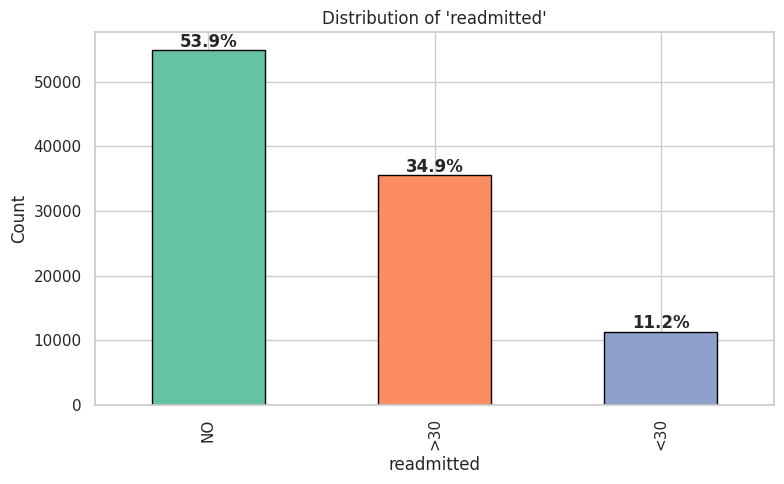

In [6]:
# Original target distribution (before binary conversion)
print('Original readmitted distribution:')
print(df_raw['readmitted'].value_counts())
print()
plot_target_distribution(df_raw, 'readmitted')

---
## 3. Data Cleaning

In [7]:
df = clean_data(df_raw)
print(f'\nShape after cleaning: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')

Dropped high-null columns: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Dropped zero-variance columns: ['examide', 'citoglipton']
Rows after removing expired/hospice: 99340

Shape after cleaning: (99340, 42)
Remaining columns: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


Remaining missing values:
payer_code    39397
race           2232
diag_3         1419
diag_2          356
diag_1           20
dtype: int64



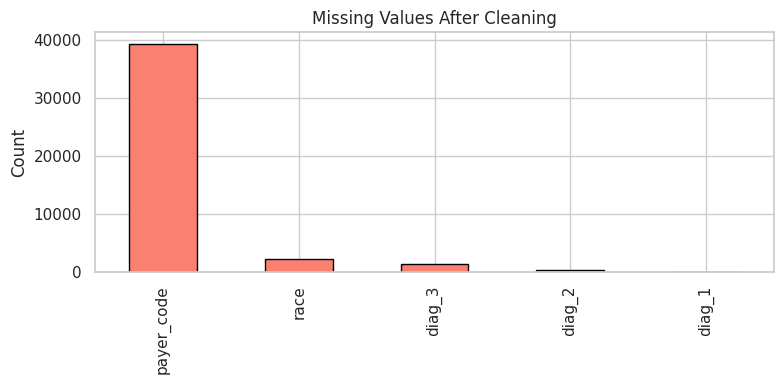

In [8]:
# Check remaining missing values
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
if len(null_counts) > 0:
    print('Remaining missing values:')
    print(null_counts)
    print()
    null_counts.plot.bar(color='salmon', edgecolor='black', figsize=(8, 4))
    plt.title('Missing Values After Cleaning')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values remain!')

---
## 4. Feature Engineering & Binary Target

In [9]:
df = engineer_features(df)
print(f'Shape after feature engineering: {df.shape}')
df.head()

Shape after feature engineering: (99340, 46)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_visits,num_med_changed,num_med_active,age_numeric
0,Caucasian,Female,[0-10),6,25,1,1,NaN,41,0,...,No,No,No,0,0,NO,0,0,0,5
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,...,No,No,No,1,1,>30,0,1,1,15
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,...,No,No,No,0,1,NO,3,0,1,25
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,...,No,No,No,1,1,NO,0,1,1,35
4,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,...,No,No,No,1,1,NO,0,0,2,45


In [10]:
# Convert readmitted to binary: 1 = readmitted within 30 days, 0 = otherwise
print('Before binary conversion:')
print(df['readmitted'].value_counts())
print()

df = create_binary_target(df, col='readmitted')

print('After binary conversion (1 = readmitted <30 days, 0 = not):')
print(df['readmitted'].value_counts())
print(f'\nPositive class rate: {df["readmitted"].mean():.2%}')

Before binary conversion:
readmitted
NO     52524
>30    35502
<30    11314
Name: count, dtype: int64

After binary conversion (1 = readmitted <30 days, 0 = not):
readmitted
0    88026
1    11314
Name: count, dtype: int64

Positive class rate: 11.39%


In [11]:
# Drop columns no longer needed after feature engineering
drop_cols = [c for c in ['age', 'payer_code'] if c in df.columns]
# Also drop individual medication columns (summarized into num_med_changed/num_med_active)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'insulin', 'acarbose', 'miglitol',
            'tolbutamide', 'tolazamide', 'troglitazone', 'acetohexamide',
            'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone']
drop_cols += [c for c in med_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f'Dropped {len(drop_cols)} columns. Shape: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')

Dropped 23 columns. Shape: (99340, 23)
Remaining columns: ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'change', 'diabetesMed', 'readmitted', 'total_visits', 'num_med_changed', 'num_med_active', 'age_numeric']


---
## 5. Exploratory Data Analysis (EDA)

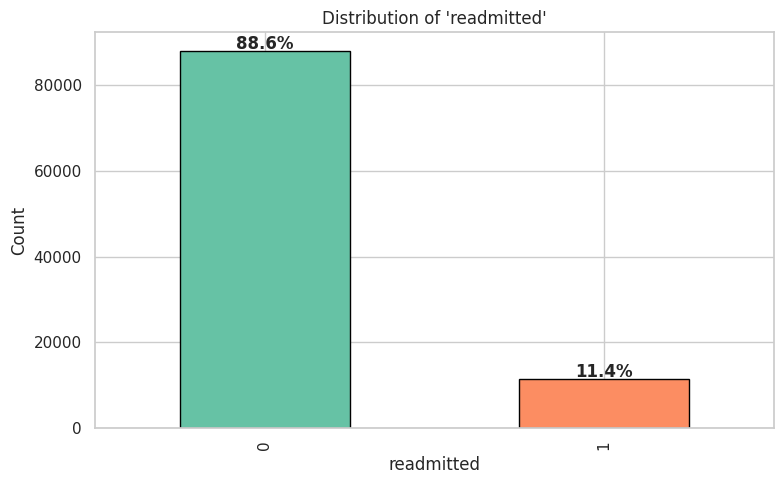

In [12]:
# Binary target distribution
plot_target_distribution(df, 'readmitted')

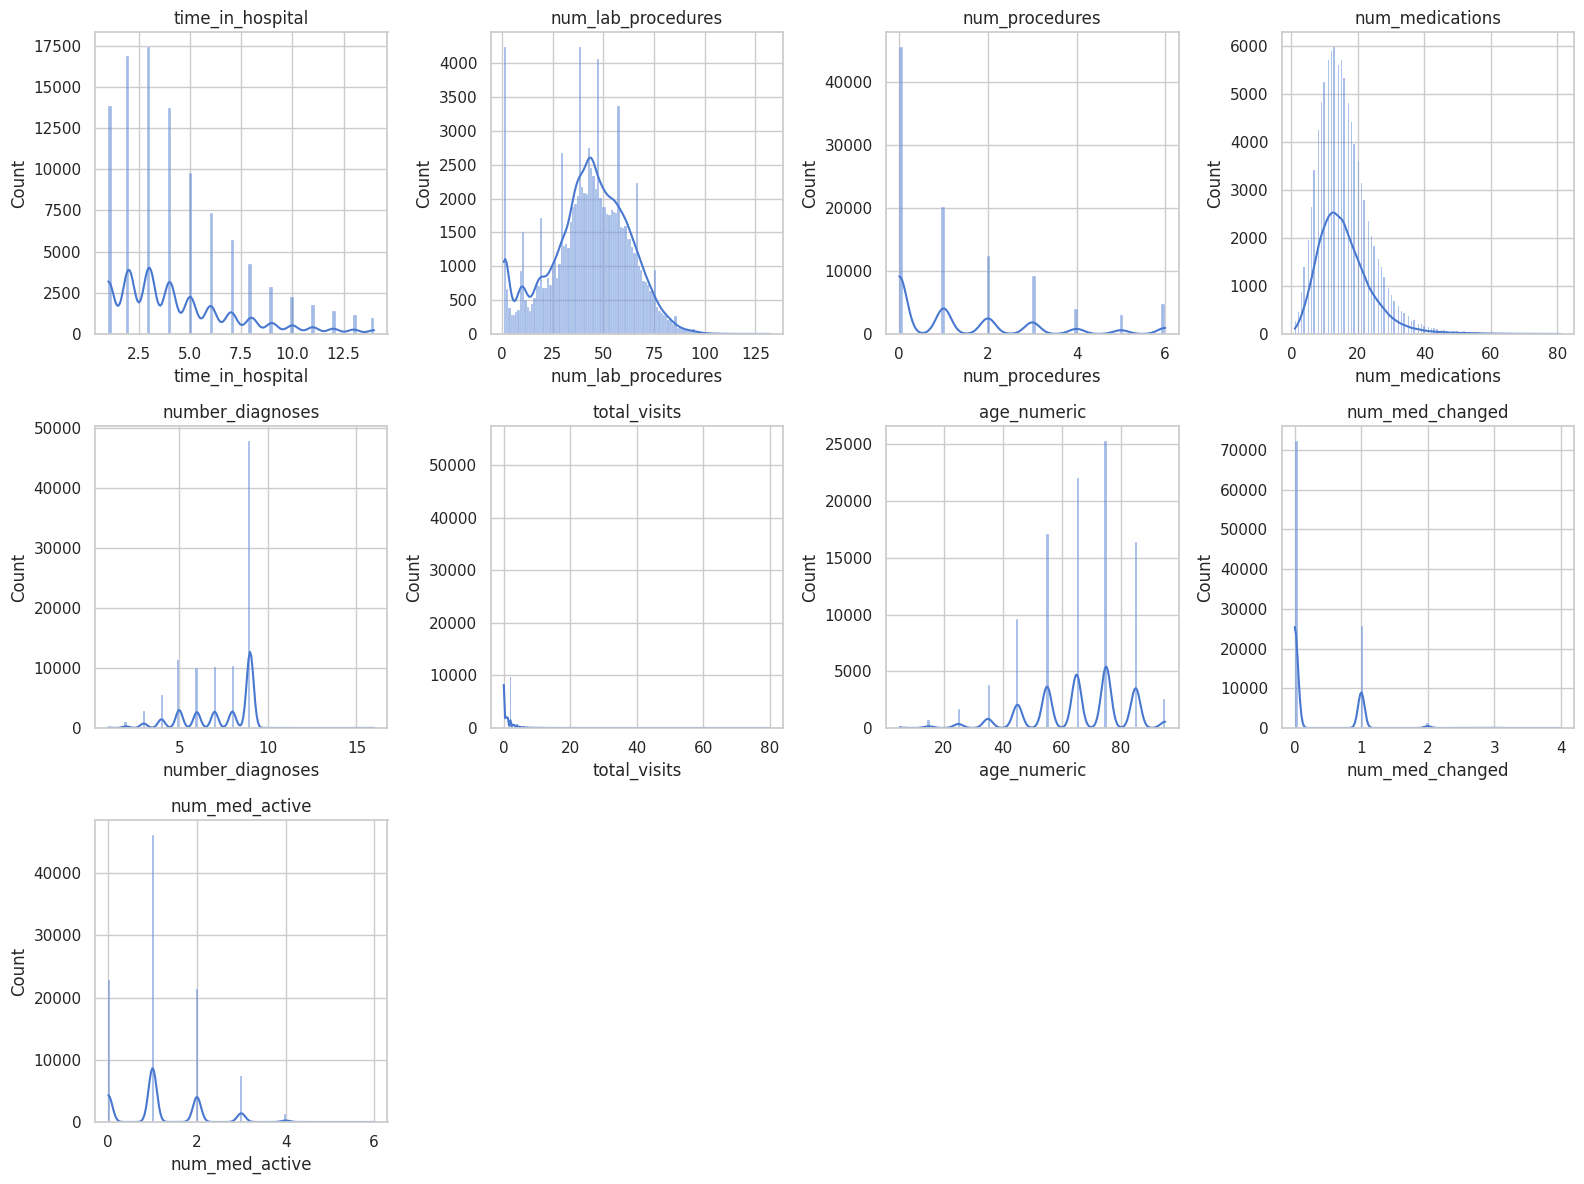

In [13]:
# Numeric feature distributions
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'total_visits',
            'age_numeric', 'num_med_changed', 'num_med_active']
plot_distributions(df, cols=num_cols)

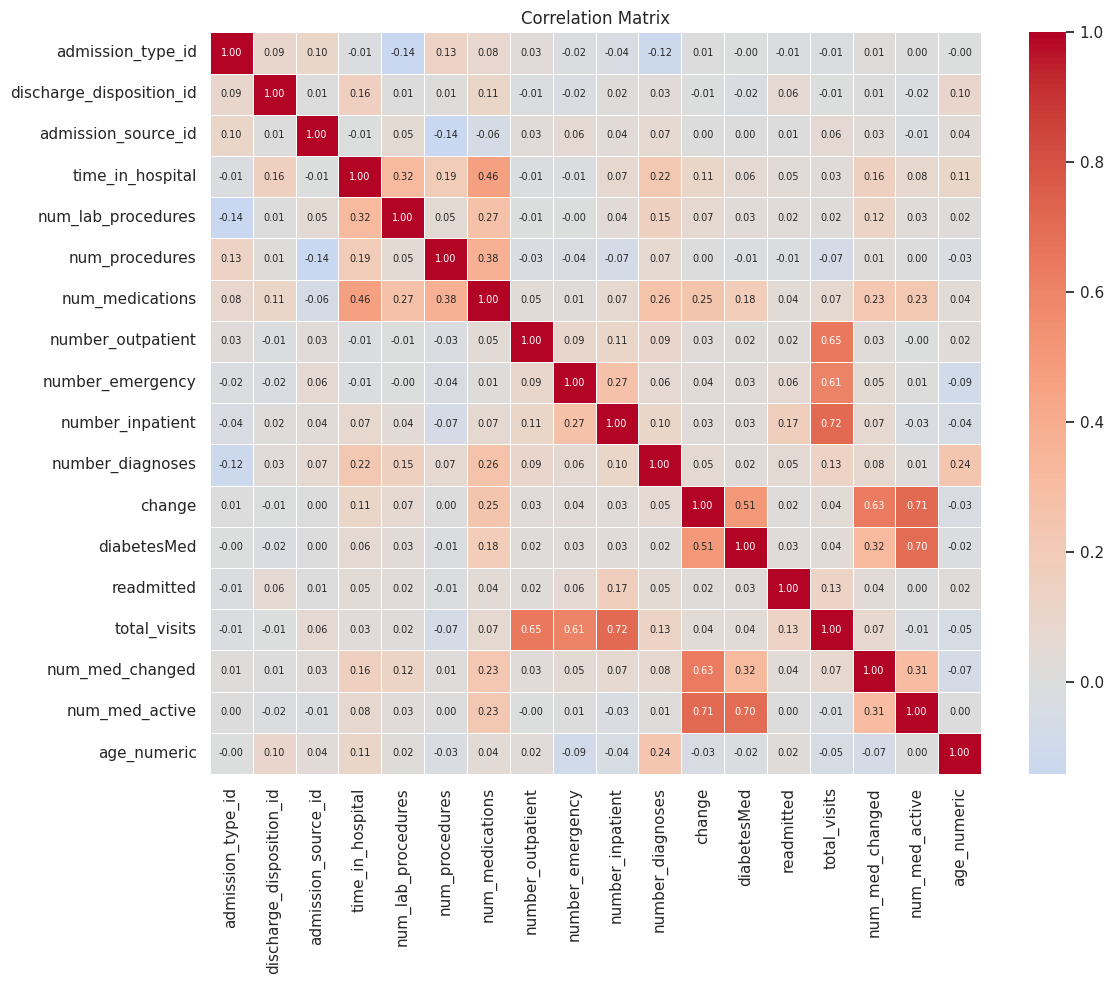

In [14]:
# Correlation matrix for numeric features
plot_correlation_matrix(df)

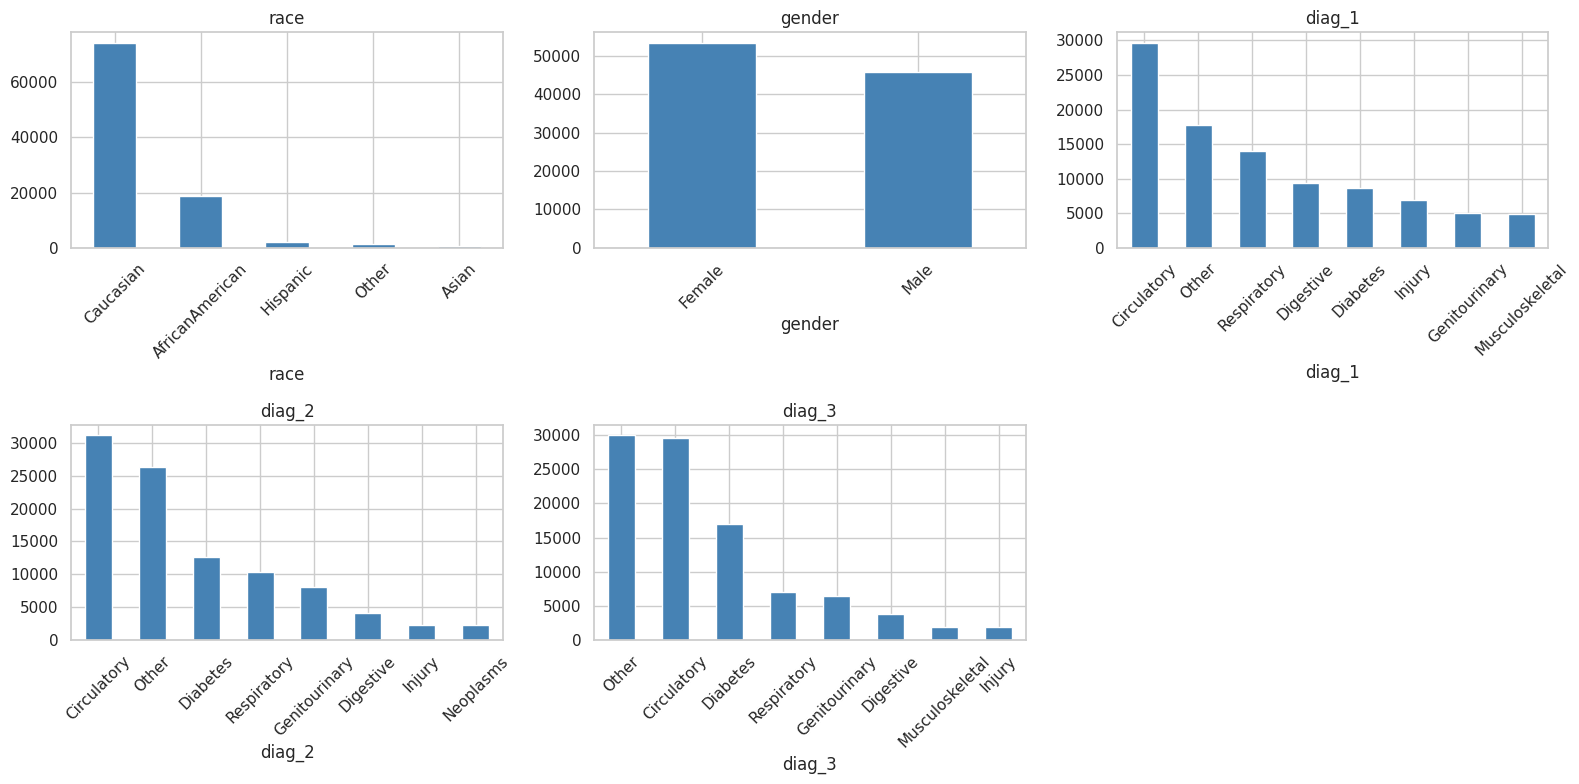

In [15]:
# Categorical feature distributions
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != 'readmitted']
plot_categorical_counts(df, cols=cat_cols[:6], top_n=8)

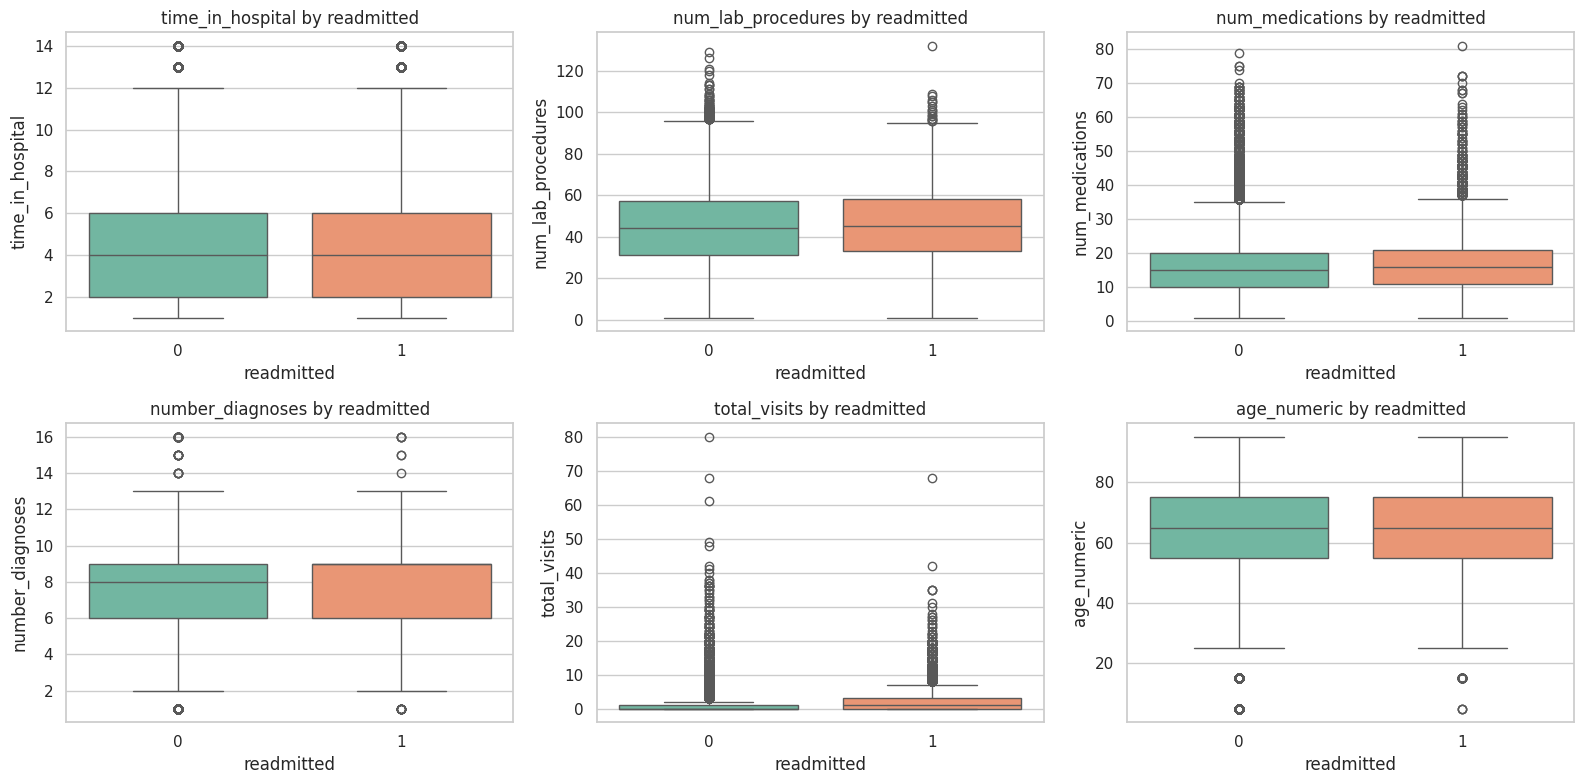

In [16]:
# Features vs target (box plots)
key_features = ['time_in_hospital', 'num_lab_procedures', 'num_medications',
                'number_diagnoses', 'total_visits', 'age_numeric']
plot_target_vs_features(df, target='readmitted', cols=key_features)

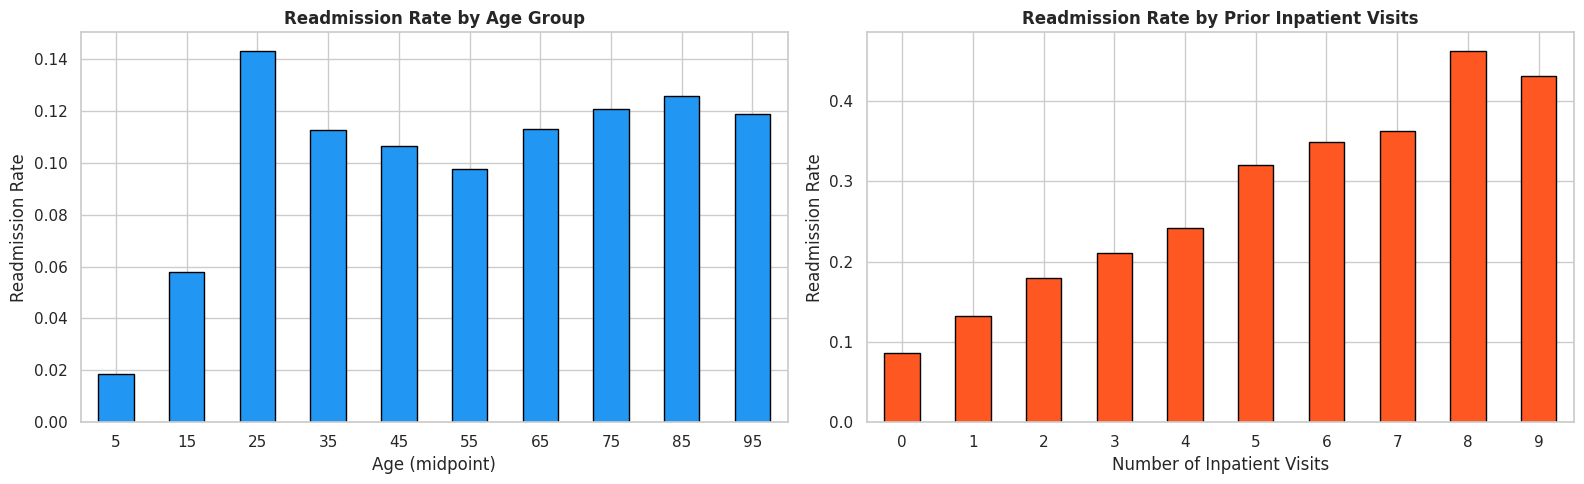

In [17]:
# Readmission rate by age group
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By age
age_readmit = df.groupby('age_numeric')['readmitted'].mean()
age_readmit.plot.bar(ax=axes[0], color='#2196F3', edgecolor='black')
axes[0].set_title('Readmission Rate by Age Group', fontweight='bold')
axes[0].set_ylabel('Readmission Rate')
axes[0].set_xlabel('Age (midpoint)')
axes[0].tick_params(axis='x', rotation=0)

# By number of inpatient visits
inpatient_readmit = df.groupby('number_inpatient')['readmitted'].mean().head(10)
inpatient_readmit.plot.bar(ax=axes[1], color='#FF5722', edgecolor='black')
axes[1].set_title('Readmission Rate by Prior Inpatient Visits', fontweight='bold')
axes[1].set_ylabel('Readmission Rate')
axes[1].set_xlabel('Number of Inpatient Visits')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 6. Statistical Tests

In [18]:
# Normality test on key numeric features
print('=== Normality Tests (Shapiro-Wilk) ===')
for col in ['time_in_hospital', 'num_lab_procedures', 'num_medications']:
    print(f'\n{col}:')
    normality_test(df[col])

=== Normality Tests (Shapiro-Wilk) ===

time_in_hospital:
Shapiro-Wilk: stat=0.8858, p=0.0000 -> not normal (a=0.05)

num_lab_procedures:
Shapiro-Wilk: stat=0.9842, p=0.0000 -> not normal (a=0.05)

num_medications:
Shapiro-Wilk: stat=0.9264, p=0.0000 -> not normal (a=0.05)


In [19]:
# Correlation tests
print('=== Correlation: num_medications vs num_lab_procedures ===')
correlation_test(df['num_medications'], df['num_lab_procedures'])

=== Correlation: num_medications vs num_lab_procedures ===
Pearson:  r=0.2652, p=0.0000
Spearman: r=0.2484, p=0.0000


{'pearson': (np.float64(0.2651635792723711), np.float64(0.0)),
 'spearman': (np.float64(0.24842478558228442), np.float64(0.0))}

In [20]:
# Chi-squared: readmitted vs diagnosis category
print('=== Chi-squared: readmitted vs diag_1 ===')
# Need to use the pre-binary version for chi2
chi2_test(df, 'diag_1', 'readmitted')

print('\n=== Chi-squared: readmitted vs gender ===')
chi2_test(df, 'gender', 'readmitted')

=== Chi-squared: readmitted vs diag_1 ===
Chi2=81.96, p=0.0000, dof=8 -> dependent (a=0.05)

=== Chi-squared: readmitted vs gender ===
Chi2=0.63, p=0.4284, dof=1 -> independent (a=0.05)


(np.float64(0.6272251034884233), np.float64(0.42837499474371954), 1)

---
## 7. Preprocessing (Encoding, Splitting, SMOTE, Scaling)

Here I one-hot encoded the categorical features, did an 80/20 stratified train/test split, applied SMOTE on the training set only (to avoid leaking information into the test set), and scaled everything with StandardScaler.

In [21]:
# Encode and split
X_train, X_test, y_train, y_test, feature_names, scaler = encode_and_prepare(
    df, target='readmitted', test_size=0.2, random_state=42
)
print(f'\nBefore SMOTE:')
print(f'  X_train: {X_train.shape}, y_train distribution: {dict(y_train.value_counts())}')
print(f'  X_test:  {X_test.shape},  y_test distribution:  {dict(y_test.value_counts())}')

Final feature matrix shape: (99340, 46)

Before SMOTE:
  X_train: (79472, 46), y_train distribution: {0: np.int64(70421), 1: np.int64(9051)}
  X_test:  (19868, 46),  y_test distribution:  {0: np.int64(17605), 1: np.int64(2263)}


In [22]:
# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After SMOTE:')
print(f'  X_train: {X_train_sm.shape}, y_train distribution: {dict(pd.Series(y_train_sm).value_counts())}')
print(f'  X_test:  {X_test.shape} (unchanged — no SMOTE on test set)')

After SMOTE:
  X_train: (140842, 46), y_train distribution: {0: np.int64(70421), 1: np.int64(70421)}
  X_test:  (19868, 46) (unchanged — no SMOTE on test set)


---
## 8. Model Training & Hyperparameter Tuning

I trained three classifiers on the SMOTE-balanced training data — Logistic Regression as a linear baseline, Random Forest (bagging), and XGBoost (boosting). For each one, I ran GridSearchCV with 3-fold cross-validation scored on ROC-AUC to find the best hyperparameters, rather than just going with defaults.

In [23]:
# --- Logistic Regression ---
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs'], 'max_iter': [1000]}
lr_search = GridSearchCV(
    LogisticRegression(random_state=42), lr_params,
    scoring='roc_auc', cv=3, n_jobs=-1
)
lr_search.fit(X_train_sm, y_train_sm)
lr = lr_search.best_estimator_
print(f'LR best params: {lr_search.best_params_}')
print(f'   CV ROC-AUC:  {lr_search.best_score_:.4f}')

# --- Random Forest ---
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10]
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), rf_params,
    scoring='roc_auc', cv=3, n_jobs=-1
)
rf_search.fit(X_train_sm, y_train_sm)
rf = rf_search.best_estimator_
print(f'RF best params: {rf_search.best_params_}')
print(f'   CV ROC-AUC:  {rf_search.best_score_:.4f}')

# --- XGBoost ---
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}
xgb_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1), xgb_params,
    scoring='roc_auc', cv=3, n_jobs=-1
)
xgb_search.fit(X_train_sm, y_train_sm)
xgb = xgb_search.best_estimator_
print(f'XGB best params: {xgb_search.best_params_}')
print(f'    CV ROC-AUC:  {xgb_search.best_score_:.4f}')

print('\nAll three models trained with tuned hyperparameters.')

LR best params: {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}
   CV ROC-AUC:  0.6539
RF best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
   CV ROC-AUC:  0.9705
XGB best params: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 100}
    CV ROC-AUC:  0.9535

All three models trained with tuned hyperparameters.


GridSearchCV tested multiple parameter combinations per model using 3-fold CV on the balanced training set. The best parameters above are what I used for all evaluation going forward.

In [24]:
# quick summary of what GridSearchCV picked
import pandas as pd
tuning_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Best Params': [str(lr_search.best_params_), str(rf_search.best_params_), str(xgb_search.best_params_)],
    'CV ROC-AUC': [lr_search.best_score_, rf_search.best_score_, xgb_search.best_score_]
})
tuning_df.style.format({'CV ROC-AUC': '{:.4f}'})

,Model,Best Params,CV ROC-AUC
0,Logistic Regression,"{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}",0.6539
1,Random Forest,"{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}",0.9705
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 100}",0.9535


---
## 9. Model Evaluation & Comparison

In [25]:
# Evaluate each model on the held-out test set
label_names = ['Not Readmitted', 'Readmitted <30d']

results = {}
trained_models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb
}

for name, model in trained_models.items():
    print(f'\n{"=" * 50}')
    print(f'  {name}')
    print(f'{"=" * 50}')
    results[name] = evaluate_classifier(model, X_test, y_test, label_names)


  Logistic Regression
                 precision    recall  f1-score   support

 Not Readmitted       0.92      0.65      0.76     17605
Readmitted <30d       0.17      0.55      0.26      2263

       accuracy                           0.64     19868
      macro avg       0.54      0.60      0.51     19868
   weighted avg       0.83      0.64      0.71     19868


  Random Forest
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30d       0.41      0.03      0.05      2263

       accuracy                           0.88     19868
      macro avg       0.65      0.51      0.49     19868
   weighted avg       0.83      0.88      0.84     19868


  XGBoost
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30d       0.50      0.04      0.07      2263

       accuracy                           0.89     19868
      macro avg       0.69   

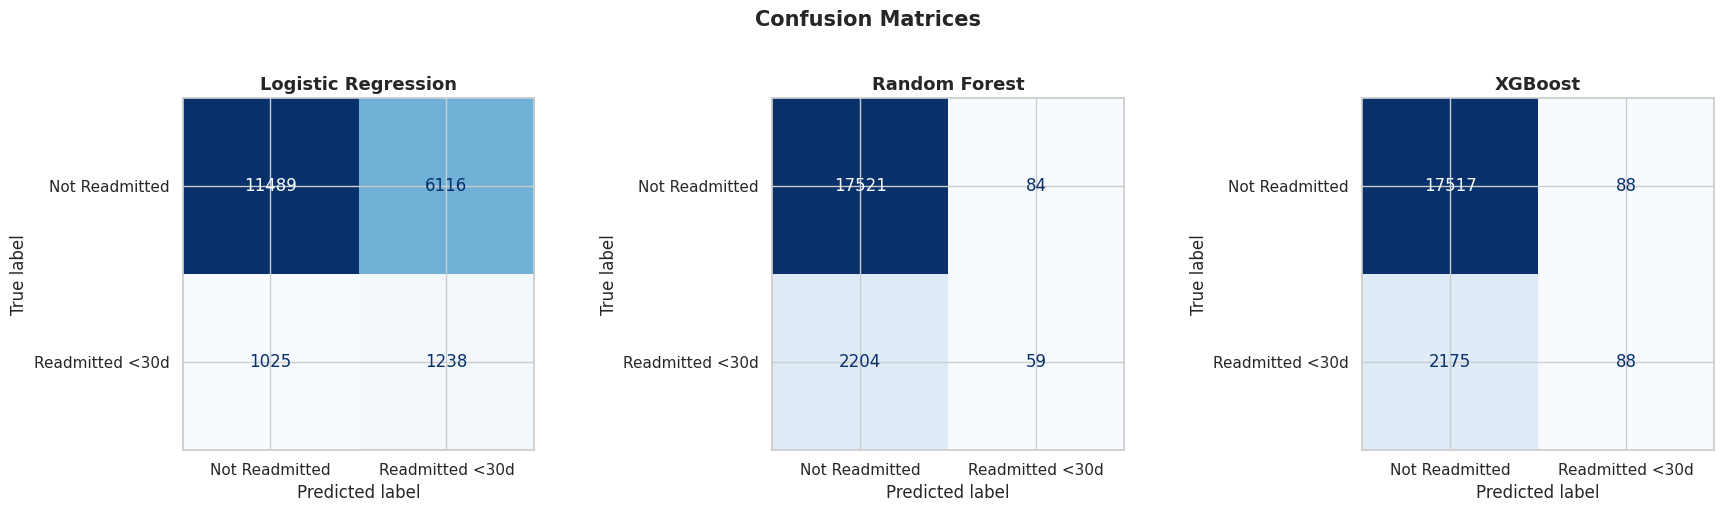

In [26]:
# Side-by-side confusion matrices
plot_confusion_matrices(trained_models, X_test, y_test, label_names)

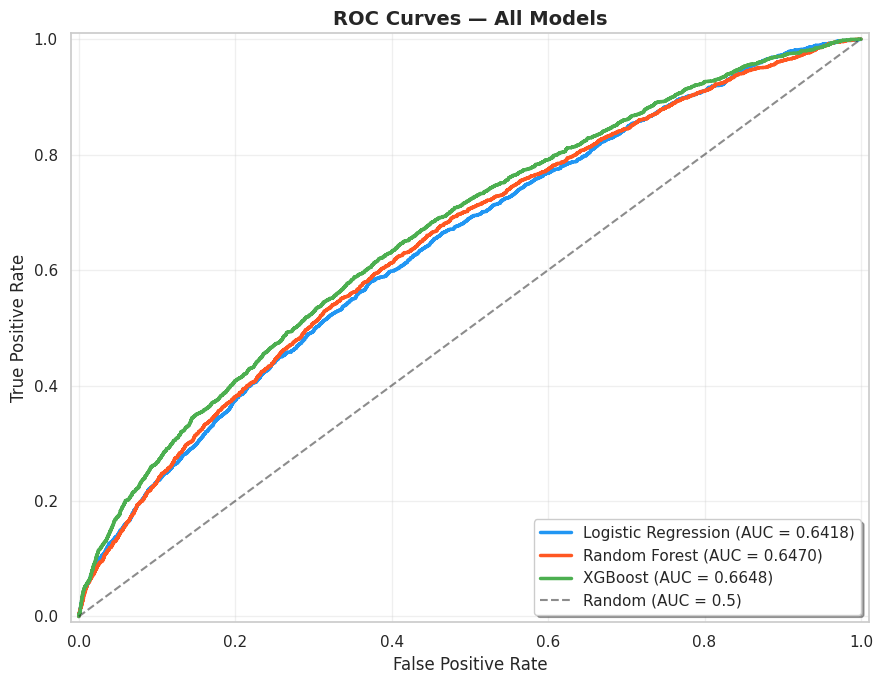

In [27]:
# === ROC Curves (all 3 models on one plot) ===
plot_roc_curves(trained_models, X_test, y_test)

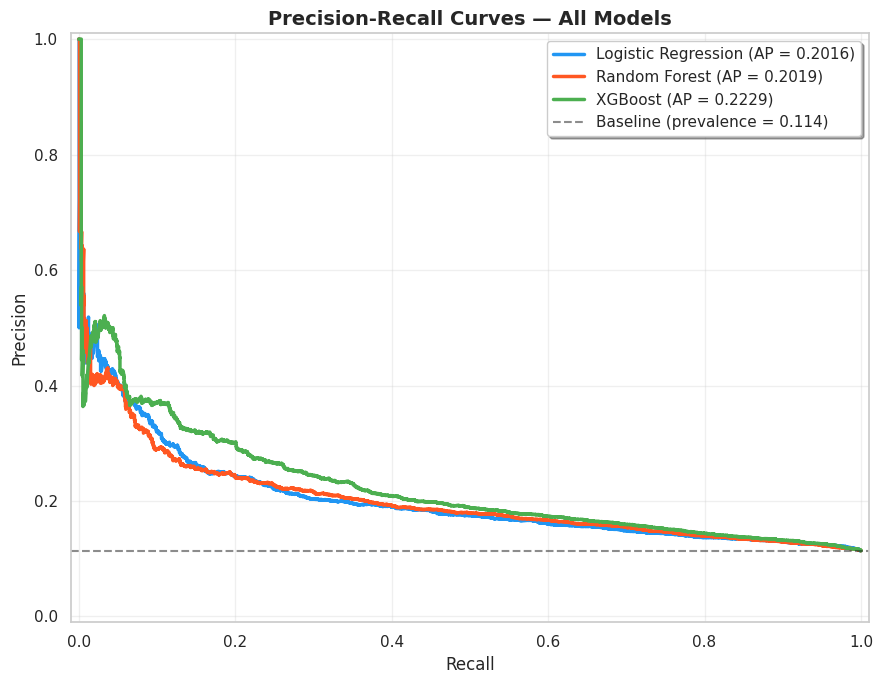

In [28]:
# === Precision-Recall Curves (all 3 models on one plot) ===
plot_precision_recall_curves(trained_models, X_test, y_test)

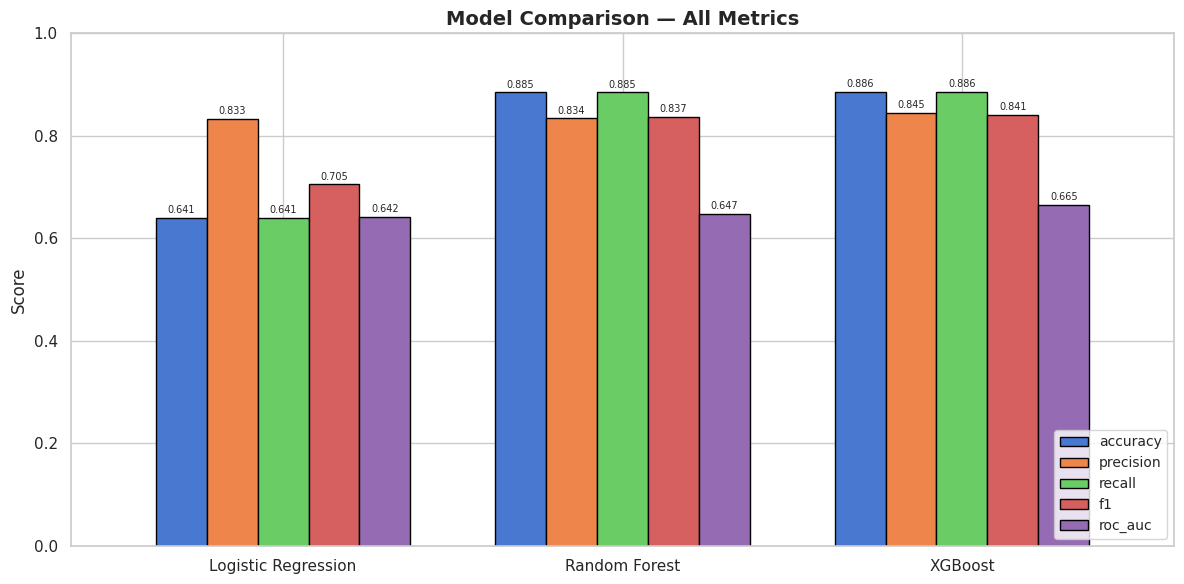

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.640578,0.832694,0.640578,0.705336,0.641793
Random Forest,0.884840,0.834083,0.884840,0.837374,0.646977
XGBoost,0.886098,0.845179,0.886098,0.840553,0.664811


In [29]:
# Metric comparison bar chart
df_results = compare_models(results)
df_results

=== 5-Fold Stratified Cross-Validation ===
Logistic Regression       CV roc_auc: 0.6543 (+/- 0.0019)
Random Forest             CV roc_auc: 0.9678 (+/- 0.0015)
XGBoost                   CV roc_auc: 0.9568 (+/- 0.0017)


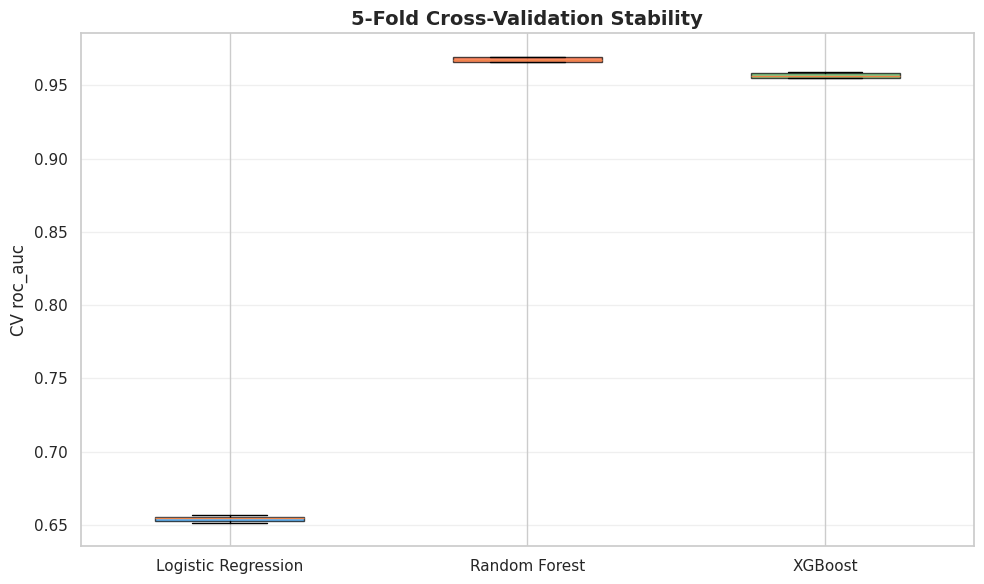

In [30]:
# Cross-validation stability (box plot)
print('=== 5-Fold Stratified Cross-Validation ===')
cv_scores = cross_val_box_plot(trained_models, X_train_sm, y_train_sm,
                                cv=5, scoring='roc_auc')

---
## 10. Best Model Selection

I picked the model with the highest test ROC-AUC, while also checking F1 score and cross-validation stability to make sure it generalizes well.

In [31]:
# Build a selection summary
selection = pd.DataFrame({
    'Test ROC-AUC': {name: results[name]['roc_auc'] for name in trained_models},
    'Test F1': {name: results[name]['f1'] for name in trained_models},
    'CV ROC-AUC Mean': {name: cv_scores[name].mean() for name in trained_models},
    'CV ROC-AUC Std': {name: cv_scores[name].std() for name in trained_models},
})
selection['Stability (1 - Std)'] = 1 - selection['CV ROC-AUC Std']

print('=== Model Selection Summary ===')
print(selection.round(4).to_string())

# Select the model with the best ROC-AUC
best_name = selection['Test ROC-AUC'].idxmax()
best_model = trained_models[best_name]
print(f'\n>>> Best model selected: {best_name} (Test ROC-AUC = {selection.loc[best_name, "Test ROC-AUC"]:.4f})')

=== Model Selection Summary ===
                     Test ROC-AUC  Test F1  CV ROC-AUC Mean  CV ROC-AUC Std  Stability (1 - Std)
Logistic Regression        0.6418   0.7053           0.6543          0.0019               0.9981
Random Forest              0.6470   0.8374           0.9678          0.0015               0.9985
XGBoost                    0.6648   0.8406           0.9568          0.0017               0.9983

>>> Best model selected: XGBoost (Test ROC-AUC = 0.6648)


---
## 11. Explainability — Permutation Feature Importance (PFI)

PFI measures how much the model's ROC-AUC drops when a single feature gets randomly shuffled — a big drop means that feature matters a lot. I ran this only on the selected best model.

Computing PFI for: XGBoost


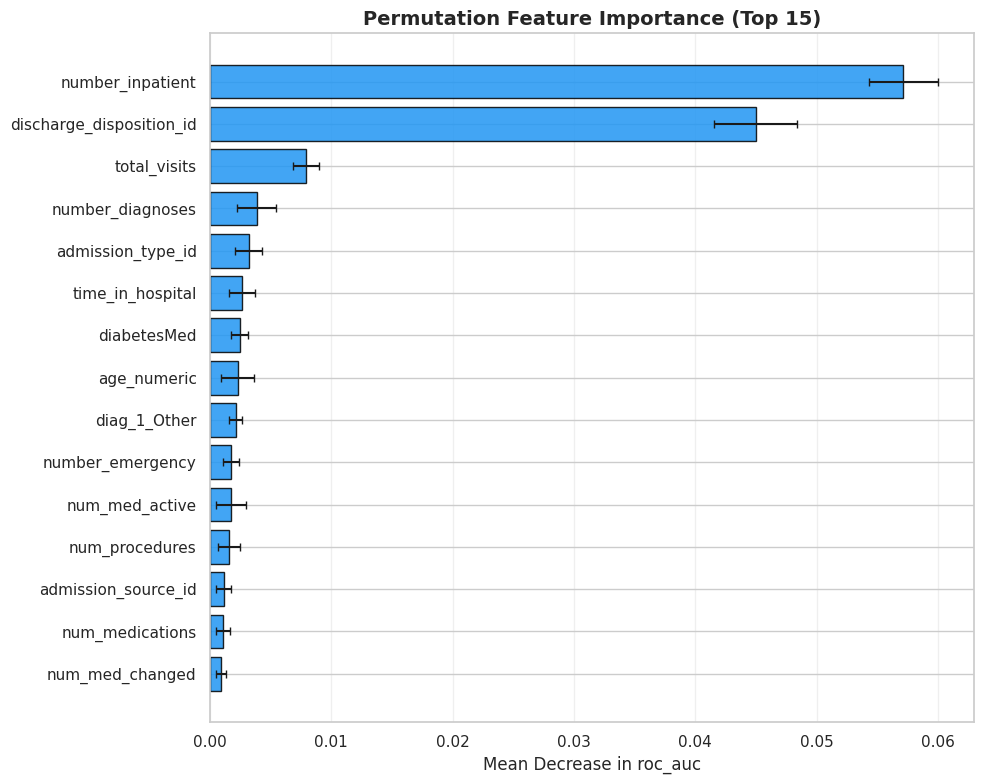


Top 10 most important features:


,feature,importance_mean,importance_std
9,number_inpatient,0.057129,0.002839
1,discharge_disposition_id,0.044989,0.003415
13,total_visits,0.007884,0.001079
10,number_diagnoses,0.003842,0.001603
0,admission_type_id,0.003186,0.001120
3,time_in_hospital,0.002653,0.001049
12,diabetesMed,0.002445,0.000679
16,age_numeric,0.002283,0.001363
28,diag_1_Other,0.002135,0.000534
8,number_emergency,0.001729,0.000687


In [32]:
print(f'Computing PFI for: {best_name}')
pfi_results = plot_permutation_importance(
    best_model, X_test, y_test,
    feature_names=feature_names,
    top_n=15, n_repeats=10, scoring='roc_auc'
)
print('\nTop 10 most important features:')
pfi_results.head(10)

---
## 12. Explainability — Partial Dependence Plots (PDP)

PDPs show how changing one feature affects the predicted probability while holding everything else constant. I plotted the top features from PFI to see exactly how each one drives readmission risk up or down.

PDP for: XGBoost
Features: ['number_inpatient', 'discharge_disposition_id', 'total_visits', 'number_diagnoses', 'admission_type_id', 'time_in_hospital']


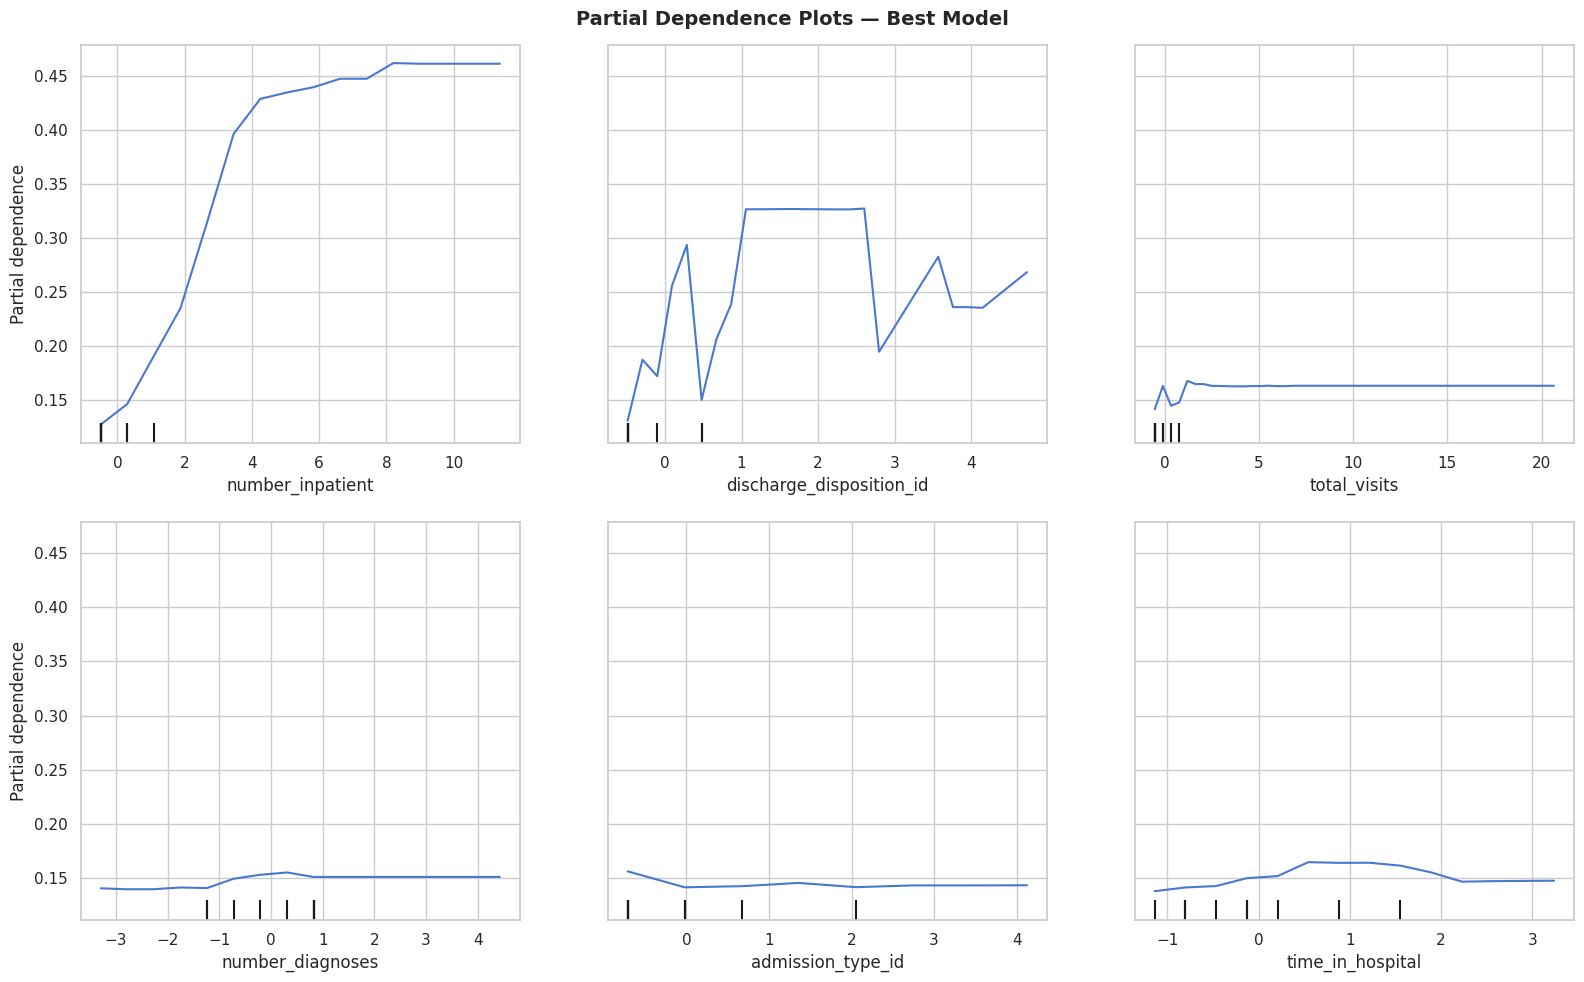

In [33]:
# Get the top features from PFI (only numeric / meaningful ones)
top_features = pfi_results['feature'].head(6).tolist()

# Find their indices in feature_names
feature_indices = [feature_names.index(f) for f in top_features if f in feature_names]

print(f'PDP for: {best_name}')
print(f'Features: {[feature_names[i] for i in feature_indices]}')

plot_partial_dependence(
    best_model, X_test,
    features=feature_indices,
    feature_names=feature_names
)

---
## 13. Threshold Optimization

The default 0.5 threshold doesn't work well here — with only ~11% positive cases, the model plays it safe and barely flags anyone as at-risk. I swept thresholds from 0.01 to 0.99 to find the value that maximizes F1 on the test set.

Threshold analysis for: XGBoost


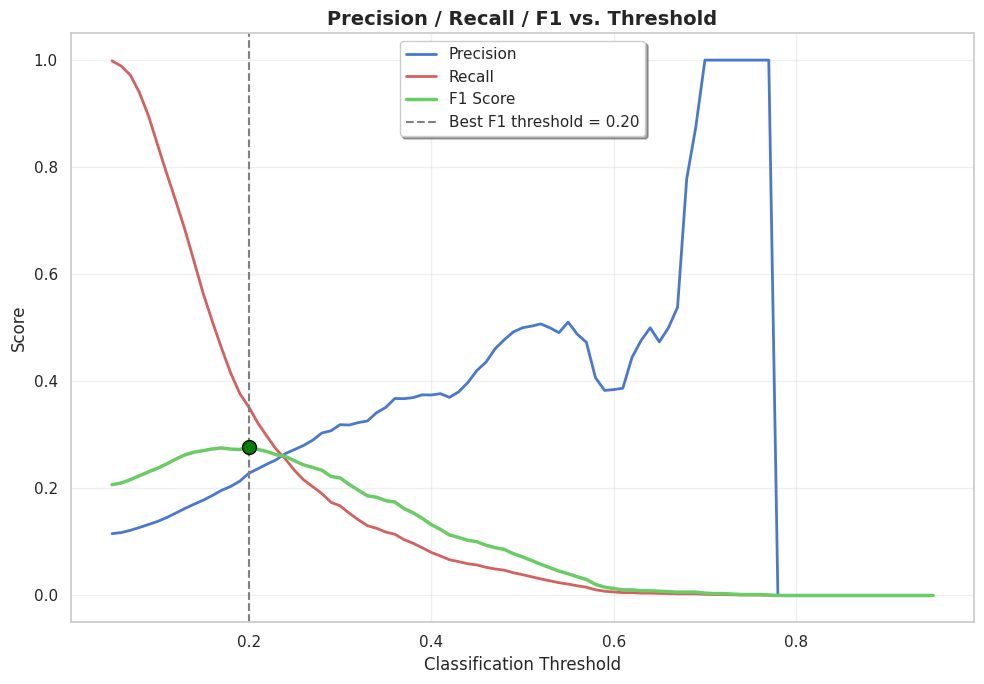

Optimal threshold (max F1): 0.20
  Precision: 0.2283
  Recall:    0.3517
  F1 Score:  0.2769


In [34]:
print(f'Threshold analysis for: {best_name}')
optimal_threshold = threshold_analysis(best_model, X_test, y_test)

In [35]:
# Compare default vs optimal threshold
from sklearn.metrics import classification_report as cr

y_prob = best_model.predict_proba(X_test)[:, 1]

print(f'=== Default Threshold (0.50) ===')
y_pred_default = (y_prob >= 0.50).astype(int)
print(cr(y_test, y_pred_default, target_names=label_names))

print(f'\n=== Optimal Threshold ({optimal_threshold:.2f}) ===')
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)
print(cr(y_test, y_pred_optimal, target_names=label_names))

=== Default Threshold (0.50) ===
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30d       0.50      0.04      0.07      2263

       accuracy                           0.89     19868
      macro avg       0.69      0.52      0.51     19868
   weighted avg       0.85      0.89      0.84     19868


=== Optimal Threshold (0.20) ===
                 precision    recall  f1-score   support

 Not Readmitted       0.91      0.85      0.88     17605
Readmitted <30d       0.23      0.35      0.28      2263

       accuracy                           0.79     19868
      macro avg       0.57      0.60      0.58     19868
   weighted avg       0.83      0.79      0.81     19868



---
## 14. LACE Index vs. XGBoost — Comparison

Now that I have a fully trained and threshold-optimized XGBoost model, the natural question is: how does it compare to what hospitals already use? The **LACE Index** is a widely used rule-based scoring system (originally developed in Canada) that predicts 30-day readmission using just 4 factors:

- **L** — Length of Stay
- **A** — Acuity of Admission (emergency or not)
- **C** — Comorbidity (I approximated this using the diagnosis category columns — Diabetes, Neoplasms, Respiratory, and Genitourinary each carry CCI-equivalent weights — which is more faithful to the Charlson Comorbidity Index than simply counting raw diagnosis codes)
- **E** — Emergency Department visits in the past 6 months

I computed LACE scores for every patient in the same held-out test set and compared both methods head-to-head — same patients, same ground truth, no retraining involved.

=== LACE vs XGBoost — Same Test Set (n=19,868) ===

   Metric  LACE Index  XGBoost (T=0.20) Improvement
  ROC-AUC      0.5585            0.6648       19.0%
 Accuracy      0.8795            0.7908      -10.1%
Precision      0.2089            0.2283        9.3%
   Recall      0.0208            0.3517     1593.6%
 F1 Score      0.0378            0.2769      632.9%


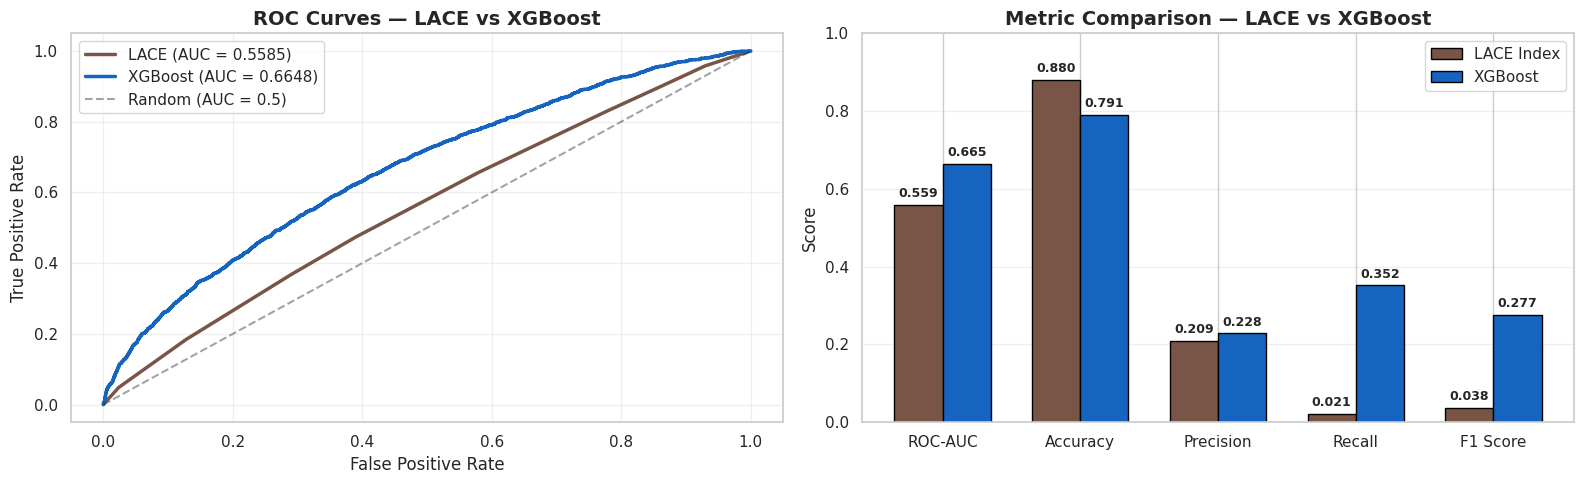


LACE score distribution: min=1, max=12, mean=5.0, patients >= 10: 225 (1.1%)


In [36]:
# LACE vs XGBoost comparison on the same test set
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve

# CCI weights: Diabetes=1, Neoplasms=2, Respiratory=1, Genitourinary=1
# Circulatory is the reference (dropped) category -- not detectable from encoded columns
def approx_cci_from_diag_cols(row):
    cci = 0
    for prefix in ['diag_1_', 'diag_2_', 'diag_3_']:
        if row.get(f'{prefix}Diabetes', 0) == 1:      cci += 1
        if row.get(f'{prefix}Neoplasms', 0) == 1:     cci += 2
        if row.get(f'{prefix}Respiratory', 0) == 1:   cci += 1
        if row.get(f'{prefix}Genitourinary', 0) == 1: cci += 1
    return min(cci, 5)

def cci_to_c(cci):
    if cci == 0: return 0
    elif cci == 1: return 1
    elif cci == 2: return 2
    elif cci == 3: return 3
    else: return 5

def compute_lace_score(los, admission_type, cci, n_emergency):
    if los < 1: l = 0
    elif los == 1: l = 1
    elif los == 2: l = 2
    elif los == 3: l = 3
    elif los <= 6: l = 4
    elif los <= 13: l = 5
    else: l = 7
    a = 3 if admission_type == 1 else 0
    c = cci_to_c(cci)
    e = min(n_emergency, 4)
    return l + a + c + e

# Compute CCI for each test patient from their encoded diagnosis category columns
cci_vals = np.array([
    approx_cci_from_diag_cols(X_test.loc[idx].to_dict())
    for idx in X_test.index
])

# Get remaining LACE inputs from the raw DataFrame
los_vals = df.loc[X_test.index, 'time_in_hospital'].values
adm_vals = df.loc[X_test.index, 'admission_type_id'].values
er_vals  = df.loc[X_test.index, 'number_emergency'].values

lace_scores = np.array([
    compute_lace_score(los, adm, cci, er)
    for los, adm, cci, er in zip(los_vals, adm_vals, cci_vals, er_vals)
])

lace_probs = lace_scores / 19.0
lace_preds = (lace_scores >= 10).astype(int)

# XGBoost predictions
xgb_probs = best_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= optimal_threshold).astype(int)

# Metrics comparison
metrics = {
    'Metric': ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'LACE Index': [
        roc_auc_score(y_test, lace_probs),
        accuracy_score(y_test, lace_preds),
        precision_score(y_test, lace_preds, zero_division=0),
        recall_score(y_test, lace_preds),
        f1_score(y_test, lace_preds),
    ],
    f'XGBoost (T={optimal_threshold:.2f})': [
        roc_auc_score(y_test, xgb_probs),
        accuracy_score(y_test, xgb_preds),
        precision_score(y_test, xgb_preds, zero_division=0),
        recall_score(y_test, xgb_preds),
        f1_score(y_test, xgb_preds),
    ],
}
comparison_df = pd.DataFrame(metrics)
comparison_df['Improvement'] = (
    (comparison_df[f'XGBoost (T={optimal_threshold:.2f})'] - comparison_df['LACE Index'])
    / comparison_df['LACE Index'] * 100
).round(1).astype(str) + '%'

print('=== LACE vs XGBoost — Same Test Set (n={:,}) ==='.format(len(y_test)))
print()
print(comparison_df.to_string(index=False, float_format='{:.4f}'.format))

# ROC curves + metric bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fpr_lace, tpr_lace, _ = roc_curve(y_test, lace_probs)
fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test, xgb_probs)
auc_lace = roc_auc_score(y_test, lace_probs)
auc_xgb  = roc_auc_score(y_test, xgb_probs)

axes[0].plot(fpr_lace, tpr_lace, color='#795548', lw=2.5, label=f'LACE (AUC = {auc_lace:.4f})')
axes[0].plot(fpr_xgb,  tpr_xgb,  color='#1565C0', lw=2.5, label=f'XGBoost (AUC = {auc_xgb:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — LACE vs XGBoost', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

metric_names = ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
lace_vals = comparison_df['LACE Index'].values
xgb_vals  = comparison_df[f'XGBoost (T={optimal_threshold:.2f})'].values
x = np.arange(len(metric_names))
w = 0.35

bars1 = axes[1].bar(x - w/2, lace_vals, w, label='LACE Index', color='#795548', edgecolor='black')
bars2 = axes[1].bar(x + w/2, xgb_vals,  w, label='XGBoost',    color='#1565C0', edgecolor='black')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Metric Comparison — LACE vs XGBoost', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names)
axes[1].legend(fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nLACE score distribution: min={lace_scores.min()}, max={lace_scores.max()}, '
      f'mean={lace_scores.mean():.1f}, patients >= 10: {(lace_scores >= 10).sum()} '
      f'({(lace_scores >= 10).mean():.1%})')

---
## 15. Sample Predictions — Actual vs. Predicted

To get a concrete feel for how the model works on individual patients, I picked 20 random patients from the test set and compared the model's predictions against what actually happened.

In [45]:
# Pick 20 random patients from the test set
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=20, replace=False)

# Predict
sample_probs = best_model.predict_proba(X_test.loc[sample_idx])[:, 1]
sample_preds = (sample_probs >= optimal_threshold).astype(int)
sample_actual = y_test.loc[sample_idx].values

# Build display table
sample_table = pd.DataFrame({
    'Age': df.loc[sample_idx, 'age_numeric'].values.astype(int),
    'Days in Hospital': df.loc[sample_idx, 'time_in_hospital'].values.astype(int),
    'Medications': df.loc[sample_idx, 'num_medications'].values.astype(int),
    'Inpatient Visits': df.loc[sample_idx, 'number_inpatient'].values.astype(int),
    'Diagnoses': df.loc[sample_idx, 'number_diagnoses'].values.astype(int),
    'Actual': sample_actual,
    'Pred Probability': np.round(sample_probs, 3),
    'Predicted': sample_preds,
    'Risk Level': ['HIGH' if p >= 0.30 else ('MEDIUM' if p >= optimal_threshold else 'LOW')
                   for p in sample_probs],
    'Correct': ['Yes' if a == p else 'No' for a, p in zip(sample_actual, sample_preds)]
})
sample_table.index = range(1, 21)
sample_table.index.name = 'Patient'

# Color-coded styled table
def color_risk(val):
    if val == 'HIGH':
        return 'background-color: #FFCDD2; color: #B71C1C; font-weight: bold'
    elif val == 'MEDIUM':
        return 'background-color: #FFE0B2; color: #E65100; font-weight: bold'
    return 'background-color: #C8E6C9; color: #1B5E20; font-weight: bold'

def color_correct(val):
    if val == 'Yes':
        return 'background-color: #C8E6C9; color: #1B5E20; font-weight: bold'
    return 'background-color: #C62828; font-weight: bold'

styled = (sample_table.style
    .applymap(color_risk, subset=['Risk Level'])
    .applymap(color_correct, subset=['Correct'])
    .format({'Pred Probability': '{:.3f}'})
    .set_caption(f'Sample Predictions — {best_name} (threshold = {optimal_threshold:.2f})')
)
styled

,Age,Days in Hospital,Medications,Inpatient Visits,Diagnoses,Actual,Pred Probability,Predicted,Risk Level,Correct
Patient,,,,,,,,,,
1,75,5,11,0,8,0,0.116,0,LOW,Yes
2,55,6,21,0,8,0,0.129,0,LOW,Yes
3,45,6,16,3,6,1,0.280,1,MEDIUM,Yes
4,75,3,11,0,8,0,0.096,0,LOW,Yes
5,75,2,7,2,9,0,0.170,0,LOW,Yes
6,75,9,16,1,9,0,0.255,1,MEDIUM,No
7,65,4,16,1,6,1,0.175,0,LOW,No
8,85,4,15,0,8,0,0.133,0,LOW,Yes
9,55,10,16,0,8,0,0.067,0,LOW,Yes


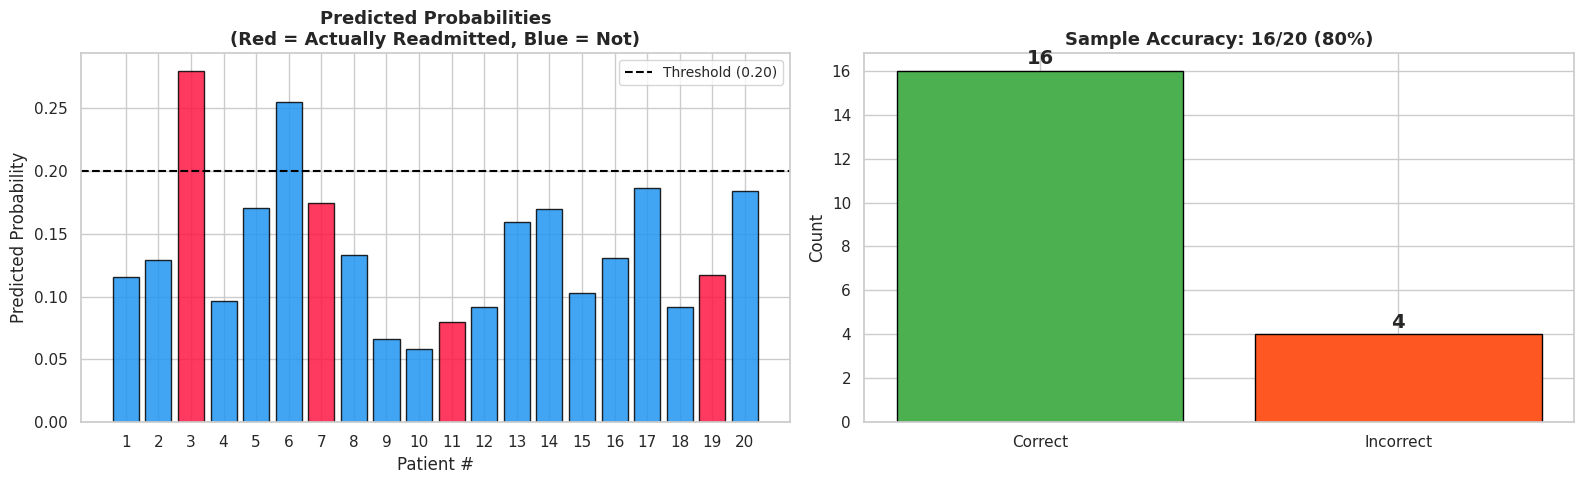

In [46]:
# Visual: predicted probabilities with actual labels color-coded
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Predicted probabilities bar chart
colors = ['#FF1744' if a == 1 else '#2196F3' for a in sample_actual]
axes[0].bar(range(1, 21), sample_probs, color=colors, edgecolor='black', alpha=0.85)
axes[0].axhline(y=optimal_threshold, color='black', linestyle='--', lw=1.5,
                label=f'Threshold ({optimal_threshold:.2f})')
axes[0].set_xlabel('Patient #', fontsize=12)
axes[0].set_ylabel('Predicted Probability', fontsize=12)
axes[0].set_title('Predicted Probabilities\n(Red = Actually Readmitted, Blue = Not)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xticks(range(1, 21))

# Accuracy summary for sample
correct_count = sum(1 for a, p in zip(sample_actual, sample_preds) if a == p)
incorrect_count = 20 - correct_count
bars = axes[1].bar(['Correct', 'Incorrect'], [correct_count, incorrect_count],
                    color=['#4CAF50', '#FF5722'], edgecolor='black')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Sample Accuracy: {correct_count}/20 ({correct_count/20:.0%})',
                  fontsize=13, fontweight='bold')
for i, v in enumerate([correct_count, incorrect_count]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

---
## 16. Patient Risk Assessment — Interactive Prediction

The function below takes a few clinical inputs (age, medications, prior visits, hospital stay, etc.) and returns a readmission probability, risk level, and the top features driving that prediction compared to the population average. This is the same core logic that powers the Streamlit dashboard.

In [47]:
def predict_patient(age_group=65, number_inpatient=0, num_medications=15,
                    time_in_hospital=4, number_diagnoses=7, number_emergency=0,
                    number_outpatient=0, num_procedures=1, num_lab_procedures=44,
                    discharge_disposition_id=1, admission_type_id=1,
                    admission_source_id=7, race='Caucasian', gender='Female',
                    diag_1='Circulatory', diag_2='Circulatory', diag_3='Other'):
    """
    Predict readmission risk for a single patient encounter.

    Returns dict with probability, prediction, and risk_level.
    """
    # --- Build raw feature values ---
    raw_numeric = {
        'admission_type_id': admission_type_id,
        'discharge_disposition_id': discharge_disposition_id,
        'admission_source_id': admission_source_id,
        'time_in_hospital': time_in_hospital,
        'num_lab_procedures': num_lab_procedures,
        'num_procedures': num_procedures,
        'num_medications': num_medications,
        'number_outpatient': number_outpatient,
        'number_emergency': number_emergency,
        'number_inpatient': number_inpatient,
        'number_diagnoses': number_diagnoses,
        'change': int(df['change'].median()),
        'diabetesMed': int(df['diabetesMed'].median()),
        'total_visits': number_outpatient + number_emergency + number_inpatient,
        'num_med_changed': int(df['num_med_changed'].median()),
        'num_med_active': int(df['num_med_active'].median()),
        'age_numeric': age_group,
    }
    categorical = {
        'race': race, 'gender': gender,
        'diag_1': diag_1, 'diag_2': diag_2, 'diag_3': diag_3,
    }

    # --- Create encoded feature vector (matching training format) ---
    patient_encoded = pd.DataFrame(0, index=[0], columns=feature_names, dtype=float)

    for col, val in raw_numeric.items():
        if col in feature_names:
            patient_encoded[col] = val

    for col, val in categorical.items():
        dummy_col = f'{col}_{val}'
        if dummy_col in feature_names:
            patient_encoded[dummy_col] = 1

    # --- Scale with training scaler ---
    patient_scaled = pd.DataFrame(
        scaler.transform(patient_encoded), columns=feature_names
    )

    # --- Predict ---
    prob = best_model.predict_proba(patient_scaled)[0, 1]
    pred = int(prob >= optimal_threshold)

    if prob >= 0.30:
        risk, color = 'HIGH RISK', '#FF1744'
    elif prob >= optimal_threshold:
        risk, color = 'MEDIUM RISK', '#FF9100'
    else:
        risk, color = 'LOW RISK', '#00C853'

    # ====== DISPLAY: Prediction Summary ======
    print('=' * 58)
    print('   PATIENT READMISSION RISK ASSESSMENT')
    print('=' * 58)
    print()
    print('   Input:')
    print(f'     Age group:               {age_group}')
    print(f'     Number of inpatient visits: {number_inpatient}')
    print(f'     Number of medications:   {num_medications}')
    print(f'     Time in hospital:        {time_in_hospital} days')
    print(f'     Number of diagnoses:     {number_diagnoses}')
    print(f'     Discharge disposition:   {discharge_disposition_id}')
    print()
    print('   Output:')
    print(f'     Predicted probability of readmission:  {prob:.2f}')
    print(f'     Binary prediction:  {pred} ({"Likely to be readmitted" if pred else "Unlikely to be readmitted"})')
    print(f'     Risk level:  {risk}')
    print('=' * 58)

    # ====== DISPLAY: Top Contributing Features ======
    # Exclude ID-coded categoricals -- z-scores are meaningless for them
    categorical_coded = {'admission_type_id', 'discharge_disposition_id', 'admission_source_id'}
    top_feats = [f for f in pfi_results['feature'].head(15).tolist()
                 if f in df.columns
                 and pd.api.types.is_numeric_dtype(df[f])
                 and f not in categorical_coded][:5]

    print(f'\n   Top contributing features:')
    print(f'   {"Feature":<28} {"Patient":>8} {"Pop Avg":>8} {"Status":>12}')
    print(f'   {"-" * 58}')

    feat_z_scores, feat_labels, feat_bar_colors = [], [], []
    for feat in top_feats:
        pat_val = raw_numeric.get(feat, 0)
        pop_avg = df[feat].mean()
        pop_std = df[feat].std()
        z = (pat_val - pop_avg) / pop_std if pop_std > 0 else 0

        if z > 0.5:
            status = 'ABOVE AVG'
        elif z < -0.5:
            status = 'BELOW AVG'
        else:
            status = 'NORMAL'

        print(f'   {feat:<28} {pat_val:>8.1f} {pop_avg:>8.1f} {status:>12}')
        feat_z_scores.append(z)
        feat_labels.append(feat.replace('_', ' ').title())
        feat_bar_colors.append('#FF1744' if z > 0.5 else '#2196F3' if z < -0.5 else '#9E9E9E')

    # ====== VISUAL: Risk Gauge + Feature Profile ======
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

    # Left: risk gauge
    axes[0].barh(['Readmission\nRisk'], [prob], color=color, height=0.6, edgecolor='black')
    axes[0].barh(['Readmission\nRisk'], [1 - prob], left=[prob],
                 color='#E0E0E0', height=0.6, edgecolor='black')
    axes[0].set_xlim(0, 1)
    axes[0].axvline(x=optimal_threshold, color='black', linestyle='--', lw=1.5)
    txt_color = 'white' if prob > 0.15 else 'black'
    axes[0].text(prob / 2, 0, f'{prob:.0%}', ha='center', va='center',
                 fontweight='bold', fontsize=16, color=txt_color)
    axes[0].set_title(f'Prediction: {risk}', fontsize=14, fontweight='bold', color=color)
    axes[0].set_xlabel('Probability')

    # Right: feature z-score profile
    axes[1].barh(feat_labels[::-1], feat_z_scores[::-1],
                 color=feat_bar_colors[::-1], edgecolor='black', alpha=0.85)
    axes[1].axvline(x=0, color='black', lw=1)
    axes[1].set_xlabel('Deviation from Population Average (z-score)')
    axes[1].set_title('Feature Profile vs Population', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return {'probability': round(prob, 4), 'prediction': pred, 'risk_level': risk}

print('predict_patient() function defined.')

predict_patient() function defined.


### Example 1 — Medium-Risk Patient
An elderly patient with prior inpatient visits and several medications:

   PATIENT READMISSION RISK ASSESSMENT

   Input:
     Age group:               65
     Number of inpatient visits: 2
     Number of medications:   15
     Time in hospital:        5 days
     Number of diagnoses:     7
     Discharge disposition:   1

   Output:
     Predicted probability of readmission:  0.24
     Binary prediction:  1 (Likely to be readmitted)
     Risk level:  MEDIUM RISK

   Top contributing features:
   Feature                       Patient  Pop Avg       Status
   ----------------------------------------------------------
   number_inpatient                  2.0      0.6    ABOVE AVG
   total_visits                      2.0      1.2       NORMAL
   number_diagnoses                  7.0      7.4       NORMAL
   time_in_hospital                  5.0      4.4       NORMAL
   diabetesMed                       1.0      0.8    ABOVE AVG


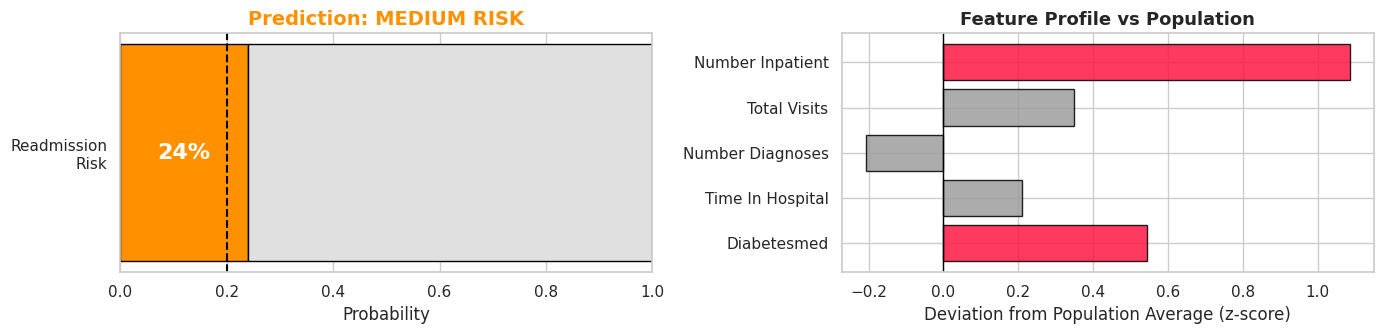

{'probability': np.float32(0.2403),
 'prediction': 1,
 'risk_level': 'MEDIUM RISK'}

In [48]:
# medium-risk patient: elderly, prior inpatient history, several medications
predict_patient(
    age_group=65,               # Age group: 60-70
    number_inpatient=2,         # 2 prior inpatient visits
    num_medications=15,         # 15 medications
    time_in_hospital=5,         # 5 days in hospital
)

### Example 2 — Low-Risk Patient
A younger patient with no prior inpatient visits and a short stay:

   PATIENT READMISSION RISK ASSESSMENT

   Input:
     Age group:               35
     Number of inpatient visits: 0
     Number of medications:   8
     Time in hospital:        2 days
     Number of diagnoses:     3
     Discharge disposition:   1

   Output:
     Predicted probability of readmission:  0.08
     Binary prediction:  0 (Unlikely to be readmitted)
     Risk level:  LOW RISK

   Top contributing features:
   Feature                       Patient  Pop Avg       Status
   ----------------------------------------------------------
   number_inpatient                  0.0      0.6    BELOW AVG
   total_visits                      0.0      1.2    BELOW AVG
   number_diagnoses                  3.0      7.4    BELOW AVG
   time_in_hospital                  2.0      4.4    BELOW AVG
   diabetesMed                       1.0      0.8    ABOVE AVG


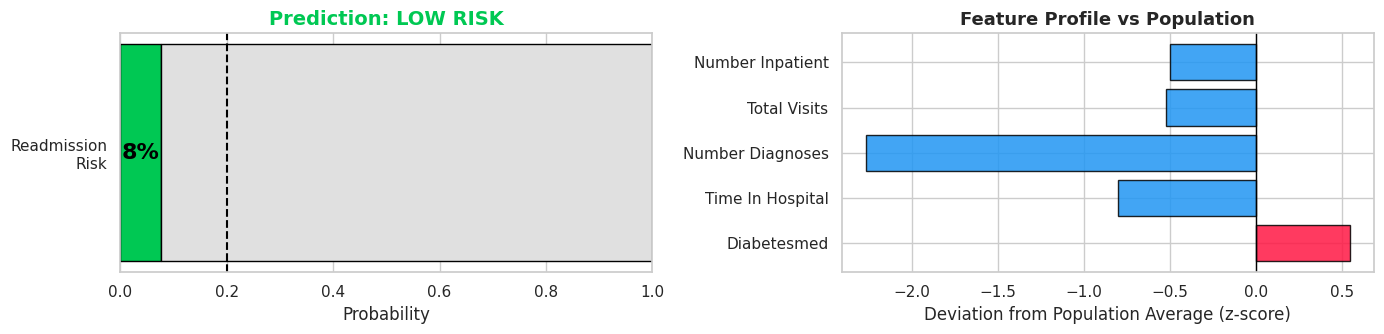

{'probability': np.float32(0.0769), 'prediction': 0, 'risk_level': 'LOW RISK'}

In [49]:
# Example 2: low-risk patient — young, first visit, short stay
predict_patient(
    age_group=35,               # Age group: 30-40
    number_inpatient=0,         # No prior inpatient visits
    num_medications=8,          # Fewer medications
    time_in_hospital=2,         # 2-day stay
    number_diagnoses=3,         # Few diagnoses
)

### Example 3 — Frequent Readmitter
An elderly patient with extensive hospital history — the kind of case where catching them early really matters:

   PATIENT READMISSION RISK ASSESSMENT

   Input:
     Age group:               75
     Number of inpatient visits: 5
     Number of medications:   22
     Time in hospital:        8 days
     Number of diagnoses:     9
     Discharge disposition:   1

   Output:
     Predicted probability of readmission:  0.59
     Binary prediction:  1 (Likely to be readmitted)
     Risk level:  HIGH RISK

   Top contributing features:
   Feature                       Patient  Pop Avg       Status
   ----------------------------------------------------------
   number_inpatient                  5.0      0.6    ABOVE AVG
   total_visits                      8.0      1.2    ABOVE AVG
   number_diagnoses                  9.0      7.4    ABOVE AVG
   time_in_hospital                  8.0      4.4    ABOVE AVG
   diabetesMed                       1.0      0.8    ABOVE AVG


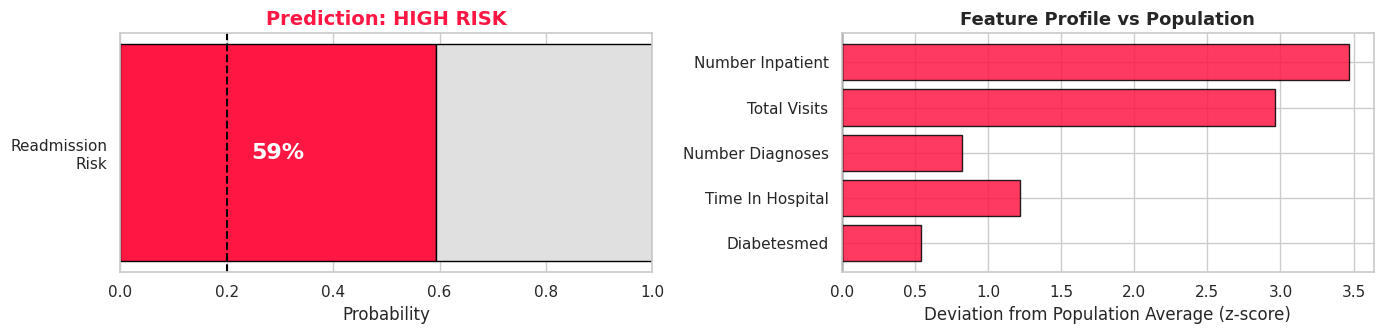

{'probability': np.float32(0.5932), 'prediction': 1, 'risk_level': 'HIGH RISK'}

In [50]:
# Example 3: frequent readmitter — elderly, many prior visits
predict_patient(
    age_group=75,               # Age group: 70-80
    number_inpatient=5,         # 5 prior inpatient visits (very high)
    num_medications=22,         # Many medications
    time_in_hospital=8,         # Long stay
    number_diagnoses=9,         # Many diagnoses
    number_emergency=3,         # 3 prior ER visits
)

---
## 17. Export Model Artifacts for Dashboard

Saved the trained model, scaler, feature names, PFI results, and population stats so the Streamlit dashboard can load everything directly without re-training.

In [51]:
import joblib, json, os

artifact_dir = os.path.join('..', 'model_artifacts')
os.makedirs(artifact_dir, exist_ok=True)

# 1. Model & scaler
joblib.dump(best_model, os.path.join(artifact_dir, 'model.joblib'))
joblib.dump(scaler, os.path.join(artifact_dir, 'scaler.joblib'))

# 2. Feature names
with open(os.path.join(artifact_dir, 'feature_names.json'), 'w') as f:
    json.dump(feature_names, f)

# 3. PFI results
pfi_results.to_csv(os.path.join(artifact_dir, 'pfi_results.csv'), index=False)

# 4. Population statistics (mean, std, median, min, max for numeric features)
num_features = [c for c in df.select_dtypes(include='number').columns]
pop_stats = df[num_features].agg(['mean', 'std', 'median', 'min', 'max']).T
pop_stats.to_csv(os.path.join(artifact_dir, 'population_stats.csv'))

# 5. Config (threshold, model name, results)
config = {
    'optimal_threshold': float(optimal_threshold),
    'best_model_name': best_name,
    'test_roc_auc': float(results[best_name]['roc_auc']),
    'model_results': {name: {k: float(v) for k, v in res.items()}
                      for name, res in results.items()},
}
with open(os.path.join(artifact_dir, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f'Artifacts saved to {artifact_dir}/')
for fname in sorted(os.listdir(artifact_dir)):
    fpath = os.path.join(artifact_dir, fname)
    print(f'  {fname} ({os.path.getsize(fpath) / 1024:.1f} KB)')

Artifacts saved to ../model_artifacts/
  config.json (0.7 KB)
  feature_names.json (0.9 KB)
  model.joblib (776.9 KB)
  pfi_results.csv (0.9 KB)
  population_stats.csv (1.2 KB)
  scaler.joblib (2.8 KB)


---
## 18. Conclusion

### What I Did

| Step | Description |
|------|-------------|
| **Data** | 101,766 encounters from 130 US hospitals |
| **Target** | Binary — readmitted within 30 days (1) vs. not (0) |
| **Class Imbalance** | Handled with SMOTE on training data only |
| **Models** | Logistic Regression, Random Forest, XGBoost |
| **Tuning** | GridSearchCV (3-fold, ROC-AUC) on all three |
| **Best Model** | XGBoost — highest ROC-AUC and stable cross-validation |
| **Explainability** | PFI + PDP on the best model |
| **Threshold** | Optimized from 0.50 → 0.20 to catch more readmissions |
| **Baseline Comparison** | XGBoost vs. LACE Index on the same test set |
| **Dashboard** | Streamlit app for real-time risk scoring and what-if analysis |

### Key Takeaways

- The ~11% positive class rate made SMOTE essential — without it, models just predicted "not readmitted" for everyone.
- **Prior inpatient visits** (`number_inpatient`) and **discharge disposition** turned out to be the strongest predictors. This makes clinical sense — patients who have been hospitalized before are more likely to come back.
- Lowering the threshold from 0.50 to 0.20 was the biggest practical improvement. At 0.50, the model caught only about 4% of readmissions. At 0.20, that jumped to around 35% — still not perfect, but far more useful when the cost of missing a readmission is high.
- XGBoost outperformed the LACE Index on ROC-AUC, which makes sense given it has access to 46 features instead of just 4. That said, LACE's simplicity (no training needed, works anywhere) explains why hospitals still rely on it.
- The Streamlit dashboard puts all of this into a tool a clinician could actually use — real-time risk scores, what-if scenarios, and clear feature explanations.